# FT370 Phase 3 Redesign — Surprise Signal Backtest
## Based on Bernanke-Kuttner (2005) methodology, per PM memo 2026-05-04

**Core change from Phase 3 v1:**
The original backtest used the T-7 Kalshi *expectation* as the sorting signal.
Bernanke & Kuttner (2005) show it is the *surprise* component that drives
asset price responses — the anticipated component is already in prices.

**New signal:** surprise_bps = decision_bps − kalshi_expected_bps_t7

**New asset universe:**
- IEI (3-7yr Treasuries) — belly of curve, cleanest Kuttner loading
- KRE (Regional Banks) — pure NIM play, replaces XLF
- ^TNX (10Y yield) — diagnostic only, not investable
- XLRE (Real Estate) — high-duration equity, supplementary
- SHY (1-3yr Treasuries) — for yield curve slope regime variable
- TLT — retained as supplementary only

**Portfolio construction:** OLS with Newey-West HAC SE (primary).
No quintile sorting. Z-score weighted position for visual/Sharpe.
Bootstrap CI [2.5%, 97.5%] on all IR/Sharpe estimates.

**Pre-registered specification:**
IEI + KRE same-day Open-to-Close OLS with surprise as RHS, HAC SE.
Run once. Report as-is.

In [1]:
# ── A: Setup ──────────────────────────────────────────────────────────────────
!pip install -q yfinance statsmodels scipy pandas numpy matplotlib seaborn

from google.colab import drive
drive.mount('/content/drive')

import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac
import yfinance as yf
from scipy import stats
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

BASE_PATH  = '/content/drive/MyDrive/FT370-s/final_project/'
DATA_PATH  = BASE_PATH + 'data/'
FIG_PATH   = BASE_PATH + 'figures/'
RESULTS_PATH = DATA_PATH + 'phase3_redesign/'
os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print("Setup complete.")

Mounted at /content/drive
Setup complete.


In [2]:
# ── Load existing parquets ────────────────────────────────────────────────────
signals           = pd.read_parquet(DATA_PATH + 'fomc_signals.parquet')
kalshi_decision   = pd.read_parquet(DATA_PATH + 'kalshi_fed_decision.parquet')
equity_existing   = pd.read_parquet(DATA_PATH + 'equity_returns.parquet')

signals['fomc_date'] = pd.to_datetime(signals['fomc_date'])
kalshi_decision['CLOSE_TIME'] = pd.to_datetime(
    kalshi_decision['CLOSE_TIME']).dt.tz_localize(None)
kalshi_decision['DATE'] = pd.to_datetime(kalshi_decision['DATE'])

# Verify decision_bps exists (critical for surprise construction)
assert 'decision_bps' in signals.columns, "decision_bps column not found in fomc_signals"
print(f"fomc_signals: {len(signals)} meetings, decision_bps range: "
      f"{signals['decision_bps'].min():.0f} to {signals['decision_bps'].max():.0f} bps")
print(f"decision_bps non-null: {signals['decision_bps'].notna().sum()} / {len(signals)}")

fomc_signals: 68 meetings, decision_bps range: -100 to 75 bps
decision_bps non-null: 68 / 68


In [3]:
# ── Download new assets via yfinance ─────────────────────────────────────────
# IEI: 3-7Y Treasury (belly of curve — cleanest Kuttner loading)
# KRE: Regional Banks (pure NIM play, replaces XLF)
# ^TNX: 10-Year yield (diagnostic, not investable)
# XLRE: Real Estate (high-duration equity, supplementary)
# SHY: 1-3Y Treasury (for yield curve slope regime variable)
# IEF: already in equity_existing but pull fresh for completeness

NEW_TICKERS = ['IEI', 'KRE', '^TNX', 'XLRE', 'SHY', 'IEF', 'TLT']
print(f"Downloading {NEW_TICKERS} from 2023-01-01 onward...")

raw = yf.download(NEW_TICKERS, start='2022-01-01', end='2026-05-01',
                  progress=False, auto_adjust=True)

# Extract Close and Open separately
closes = raw['Close'].squeeze() if hasattr(raw['Close'], 'squeeze') else raw['Close']
opens  = raw['Open'].squeeze()  if hasattr(raw['Open'],  'squeeze') else raw['Open']

closes.index = pd.to_datetime(closes.index)
opens.index  = pd.to_datetime(opens.index)

print(f"\nDownloaded: {closes.columns.tolist()}")
print(f"Date range: {closes.index.min().date()} → {closes.index.max().date()}")
print(f"\nSample (Close, last 3 rows):\n{closes.tail(3).round(3)}")


Downloaded: ['IEF', 'IEI', 'KRE', 'SHY', 'TLT', 'XLRE', '^TNX']
Date range: 2022-01-03 → 2026-04-30

Sample (Close, last 3 rows):
Ticker         IEF      IEI    KRE     SHY     TLT   XLRE   ^TNX
Date                                                            
2026-04-28  94.937  118.079  70.37  82.257  86.052  43.91  4.354
2026-04-29  94.489  117.681  69.03  82.147  85.385  43.64  4.418
2026-04-30  94.668  117.870  69.85  82.237  85.305  44.40  4.390


In [4]:
# ── Build Kalshi T-7 and T-1 expected bps ─────────────────────────────────────
# T-7: existing construction (T-10 to T-5 window)
# T-1: new construction (T-2 to T-0 window) for pre-flight corr check

def parse_bps(title):
    t = str(title).lower()
    if any(w in t for w in ['hold','unchanged','no change','no cut','no hike']):
        return 0
    num = re.search(r'(\d+)\s*bp', t)
    val = int(num.group(1)) if num else 0
    if any(w in t for w in ['cut','decreas','lower','reduc']): return -val
    if any(w in t for w in ['hike','increas','raise','higher']): return +val
    return None

kalshi_decision['implied_bps'] = kalshi_decision['MARKET_TITLE'].apply(parse_bps)
fomc_dates = sorted(signals['fomc_date'].dropna().unique())

def nearest_fomc(dt):
    if hasattr(dt, 'tzinfo') and dt.tzinfo is not None:
        dt = dt.tz_localize(None)
    future = [f for f in fomc_dates if f >= dt - pd.Timedelta(days=3)]
    return future[0] if future else pd.NaT

kalshi_decision['fomc_date'] = pd.to_datetime(
    kalshi_decision['CLOSE_TIME'].apply(nearest_fomc))

def build_kalshi_snapshot(window_start_days, window_end_days, label):
    """Build meeting-level expected bps from a T-N window."""
    records = []
    for ticker, group in kalshi_decision.groupby('MARKET_TICKER'):
        fomc_d = group['fomc_date'].iloc[0]
        if pd.isna(fomc_d): continue
        window = group[
            (group['DATE'] >= fomc_d - pd.Timedelta(days=window_start_days)) &
            (group['DATE'] <= fomc_d - pd.Timedelta(days=window_end_days))
        ]
        if window.empty: continue
        row = window.sort_values('DATE').iloc[-1]
        records.append({
            'MARKET_TICKER': ticker, 'fomc_date': fomc_d,
            'implied_bps': row['implied_bps'],
            f'price_{label}': row['PRICE_CLOSE'] / 100.0,
        })
    df = pd.DataFrame(records)
    return df.groupby('fomc_date').apply(
        lambda g: pd.Series({
            f'kalshi_expected_{label}': (g[f'price_{label}'] * g['implied_bps']).sum(),
            f'n_markets_{label}': len(g),
        })
    ).reset_index()

kalshi_t7 = build_kalshi_snapshot(10, 5, 't7')
kalshi_t1 = build_kalshi_snapshot(2, 0, 't1')

print("Kalshi T-7 snapshot:")
print(kalshi_t7[['fomc_date','kalshi_expected_t7','n_markets_t7']].round(3).to_string(index=False))

Kalshi T-7 snapshot:
 fomc_date  kalshi_expected_t7  n_markets_t7
2023-05-03                0.00           3.0
2023-06-14                5.00           4.0
2023-07-26               24.25           2.0
2023-09-20                1.00           2.0
2023-11-01                0.50           5.0
2023-12-13                0.50           3.0
2024-01-31                0.00           3.0
2024-03-20               -0.25           4.0
2024-05-01               -0.25           3.0
2024-06-12               -0.25           3.0
2024-07-31               -1.00           3.0
2024-09-18              -25.00           3.0
2024-11-07              -22.75           4.0
2024-12-18              -23.50           5.0
2025-01-29                0.00           5.0
2025-03-19               -0.25           5.0
2025-05-07               -2.25           5.0
2025-06-18               -0.75           5.0
2025-07-30               -0.75           5.0
2025-09-17              -24.00           5.0
2025-10-29              -24.00    

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# B: PRE-FLIGHT CHECKS (run before any backtest)
# ═══════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("PRE-FLIGHT CHECK 1: corr(T-7, T-1) Kalshi expected bps")
print("=" * 60)
print("If < 0.85, T-7 signal carries week-old stale info.")
print("If < 0.70, switch to T-1 as primary and acknowledge.")

both_snap = kalshi_t7.merge(kalshi_t1, on='fomc_date', how='inner')
both_snap = both_snap.dropna(subset=['kalshi_expected_t7', 'kalshi_expected_t1'])

if len(both_snap) >= 5:
    r_tt, p_tt = stats.pearsonr(both_snap['kalshi_expected_t7'],
                                 both_snap['kalshi_expected_t1'])
    print(f"\ncorr(T-7, T-1) = {r_tt:.4f}  (N={len(both_snap)})")
    if r_tt >= 0.85:
        print("✓ PASS — T-7 signal is stable. Surprise construction is clean.")
    elif r_tt >= 0.70:
        print("⚠ MARGINAL — Surprise includes some pre-announcement drift.")
        print("  Report honestly; proceed but flag in limitations.")
    else:
        print("✗ FAIL — T-7 is stale. Use T-1 expected bps instead.")

    print(f"\nScatter (T-7 vs T-1 expected bps, N={len(both_snap)}):")
    for _, row in both_snap.iterrows():
        print(f"  {str(row['fomc_date'])[:10]}: T-7={row['kalshi_expected_t7']:.2f}  "
              f"T-1={row['kalshi_expected_t1']:.2f}  "
              f"Δ={row['kalshi_expected_t1']-row['kalshi_expected_t7']:.2f}")
else:
    print(f"Only {len(both_snap)} meetings with both T-7 and T-1 data — cannot compute corr.")
    r_tt = np.nan

# Use T-1 if T-7 fails the check, T-7 otherwise
SIGNAL_COL = 'kalshi_expected_t1' if (not np.isnan(r_tt) and r_tt < 0.70) else 'kalshi_expected_t7'
print(f"\nUsing signal column: '{SIGNAL_COL}'")

PRE-FLIGHT CHECK 1: corr(T-7, T-1) Kalshi expected bps
If < 0.85, T-7 signal carries week-old stale info.
If < 0.70, switch to T-1 as primary and acknowledge.

corr(T-7, T-1) = 0.9993  (N=23)
✓ PASS — T-7 signal is stable. Surprise construction is clean.

Scatter (T-7 vs T-1 expected bps, N=23):
  2023-05-03: T-7=0.00  T-1=0.00  Δ=0.00
  2023-06-14: T-7=5.00  T-1=4.50  Δ=-0.50
  2023-07-26: T-7=24.25  T-1=25.00  Δ=0.75
  2023-09-20: T-7=1.00  T-1=0.50  Δ=-0.50
  2023-11-01: T-7=0.50  T-1=0.25  Δ=-0.25
  2023-12-13: T-7=0.50  T-1=-0.25  Δ=-0.75
  2024-01-31: T-7=0.00  T-1=0.00  Δ=0.00
  2024-03-20: T-7=-0.25  T-1=-0.50  Δ=-0.25
  2024-05-01: T-7=-0.25  T-1=-0.25  Δ=0.00
  2024-06-12: T-7=-0.25  T-1=-0.50  Δ=-0.25
  2024-07-31: T-7=-1.00  T-1=-1.00  Δ=0.00
  2024-09-18: T-7=-25.00  T-1=-26.25  Δ=-1.25
  2024-11-07: T-7=-22.75  T-1=-23.25  Δ=-0.50
  2024-12-18: T-7=-23.50  T-1=-24.25  Δ=-0.75
  2025-01-29: T-7=0.00  T-1=-0.25  Δ=-0.25
  2025-03-19: T-7=-0.25  T-1=-0.50  Δ=-0.25
  2025-05-

In [6]:
print("\n" + "=" * 60)
print("PRE-FLIGHT CHECK 2: Surprise distribution skew")
print("=" * 60)
print("If ≥18/22 meetings have same-sign surprise, level bias exists.")

# Merge with decision_bps
kalshi_signal_df = kalshi_t7.merge(kalshi_t1, on='fomc_date', how='outer')
kalshi_signal_df = kalshi_signal_df.merge(
    signals[['fomc_date','decision_bps','lm_signal']].dropna(subset=['decision_bps']),
    on='fomc_date', how='inner'
)
kalshi_signal_df = kalshi_signal_df.dropna(subset=['kalshi_expected_t7', 'decision_bps'])

# Construct surprise
kalshi_signal_df['surprise_bps'] = (
    kalshi_signal_df['decision_bps'] - kalshi_signal_df[SIGNAL_COL]
)

print(f"\nSurprise distribution (N={len(kalshi_signal_df)}):")
print(kalshi_signal_df['surprise_bps'].describe().round(3))
print(f"\nSign distribution: {(kalshi_signal_df['surprise_bps'] > 0).sum()} positive (hawkish), "
      f"{(kalshi_signal_df['surprise_bps'] < 0).sum()} negative (dovish), "
      f"{(kalshi_signal_df['surprise_bps'] == 0).sum()} zero")

n_dominant = max((kalshi_signal_df['surprise_bps'] > 0).sum(),
                  (kalshi_signal_df['surprise_bps'] < 0).sum())
if n_dominant >= int(0.75 * len(kalshi_signal_df)):
    print(f"\n⚠ SKEW WARNING: {n_dominant}/{len(kalshi_signal_df)} meetings have same sign.")
    print("  Demean surprise before regression to avoid level-signal contamination.")
    DEMEAN_SURPRISE = True
else:
    print("\n✓ Distribution is reasonably balanced.")
    DEMEAN_SURPRISE = False

if DEMEAN_SURPRISE:
    kalshi_signal_df['surprise_bps'] = (
        kalshi_signal_df['surprise_bps'] - kalshi_signal_df['surprise_bps'].mean()
    )
    print("  Surprise demeaned.")

print(f"\nMeeting-level surprise data:")
for _, row in kalshi_signal_df.sort_values('fomc_date').iterrows():
    print(f"  {str(row['fomc_date'])[:10]}: decision={row['decision_bps']:.0f}bps  "
          f"expected={row[SIGNAL_COL]:.2f}bps  surprise={row['surprise_bps']:.2f}bps")


PRE-FLIGHT CHECK 2: Surprise distribution skew
If ≥18/22 meetings have same-sign surprise, level bias exists.

Surprise distribution (N=23):
count    23.000
mean      0.761
std       9.192
min     -25.000
25%      -1.000
50%       0.250
75%       0.750
max      25.000
Name: surprise_bps, dtype: float64

Sign distribution: 12 positive (hawkish), 9 negative (dovish), 2 zero

✓ Distribution is reasonably balanced.

Meeting-level surprise data:
  2023-05-03: decision=25bps  expected=0.00bps  surprise=25.00bps
  2023-06-14: decision=0bps  expected=5.00bps  surprise=-5.00bps
  2023-07-26: decision=25bps  expected=24.25bps  surprise=0.75bps
  2023-09-20: decision=0bps  expected=1.00bps  surprise=-1.00bps
  2023-11-01: decision=0bps  expected=0.50bps  surprise=-0.50bps
  2023-12-13: decision=0bps  expected=0.50bps  surprise=-0.50bps
  2024-01-31: decision=0bps  expected=0.00bps  surprise=0.00bps
  2024-03-20: decision=0bps  expected=-0.25bps  surprise=0.25bps
  2024-05-01: decision=0bps  expe

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# C: Build open-to-close returns on FOMC meeting day
# ═══════════════════════════════════════════════════════════════════════════
# Same-day OTC = (Close[t] - Open[t]) / Open[t] on FOMC announcement day
# FOMC statement released 2pm ET; open at 9:30am is clean; close at 4pm is post-signal
# This is the cleanest yfinance approximation of the surprise-reaction window

# ETF tickers for OTC
ETF_TICKERS = ['IEI', 'KRE', 'XLRE', 'TLT', 'SHY', 'IEF']

otc_records = []

for _, row in kalshi_signal_df.iterrows():
    fomc_d  = row['fomc_date']
    record  = {
        'fomc_date':    fomc_d,
        'surprise_bps': row['surprise_bps'],
        'decision_bps': row['decision_bps'],
        'lm_signal':    row.get('lm_signal', np.nan),
    }

    # Find FOMC announcement day in close/open dataframes
    # The announcement is on fomc_d; look ±1 trading day for robustness
    for offset in [0, 1, -1]:
        day = fomc_d + pd.Timedelta(days=offset)
        if day in closes.index and day in opens.index:
            for t in ETF_TICKERS:
                if t in closes.columns and t in opens.columns:
                    c = closes.loc[day, t]
                    o = opens.loc[day, t]
                    if not pd.isna(c) and not pd.isna(o) and o > 0:
                        record[f'{t}_otc'] = (c - o) / o  # open-to-close return
            # ^TNX: change in yield level (bps equivalent), not pct return
            if '^TNX' in closes.columns and '^TNX' in opens.columns:
                tnx_c = closes.loc[day, '^TNX']
                tnx_o = opens.loc[day, '^TNX']
                if not pd.isna(tnx_c) and not pd.isna(tnx_o):
                    record['TNX_change'] = tnx_c - tnx_o  # yield point change
            break  # found the trading day, stop looking

    # Also compute 5-day Close-to-Close as robustness
    # Find the close on fomc_d and 5 trading days later
    future_days = closes[closes.index > fomc_d]
    if len(future_days) >= 5:
        for t in ETF_TICKERS:
            if t in closes.columns:
                c0 = closes.loc[fomc_d] if fomc_d in closes.index else closes[closes.index <= fomc_d].iloc[-1]
                c5 = future_days.iloc[4]
                if t in c0.index and t in c5.index and c0[t] > 0:
                    record[f'{t}_5d'] = (c5[t] - c0[t]) / c0[t]

    otc_records.append(record)

port_df = pd.DataFrame(otc_records)
port_df = port_df.dropna(subset=['surprise_bps'])

# Report coverage
otc_cols = [c for c in port_df.columns if '_otc' in c or 'TNX' in c]
print(f"Portfolio dataset: {len(port_df)} meetings")
print(f"\nOTC return coverage:")
for col in otc_cols:
    n = port_df[col].notna().sum()
    print(f"  {col}: {n}/{len(port_df)}")

Portfolio dataset: 23 meetings

OTC return coverage:
  IEI_otc: 23/23
  KRE_otc: 23/23
  XLRE_otc: 23/23
  TLT_otc: 23/23
  SHY_otc: 23/23
  IEF_otc: 23/23
  TNX_change: 23/23


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# D: PRIMARY ANALYSIS — OLS with Newey-West HAC Standard Errors
# ═══════════════════════════════════════════════════════════════════════════
# Model: return = β₀ + β₁·surprise_bps + ε
# HAC SE: Newey-West with max_lags=5 (conservative for N=22)
#
# PRIMARY specification: IEI + KRE same-day OTC
# Expected signs:
#   IEI: β₁ < 0 (more dovish surprise = more cuts delivered = IEI rallies)
#   KRE: β₁ > 0 (more hawkish surprise = higher rates = bank NIM up = KRE rallies)
#         BUT in soft-landing cutting cycle, may see β₁ < 0 (accommodation positive)
#   ^TNX: β₁ > 0 (hawkish surprise → yields rise)
#   XLRE: β₁ < 0 (hawkish surprise → higher rates hurt real estate)

print("=" * 70)
print("OLS REGRESSION WITH NEWEY-WEST HAC STANDARD ERRORS")
print("Model: return = β₀ + β₁·surprise_bps + ε")
print("Newey-West max_lags = 5 (conservative for N=22)")
print("=" * 70)

ALL_RETURN_COLS = (
    [(c.replace('_otc',''), c, 'OTC')    for c in port_df.columns if '_otc'  in c] +
    [('TNX', 'TNX_change', 'OTC')]       if 'TNX_change' in port_df.columns else [] +
    [(c.replace('_5d',''), c, '5d-Close') for c in port_df.columns if '_5d'   in c]
)
if 'TNX_change' in port_df.columns:
    ALL_RETURN_COLS.append(('TNX', 'TNX_change', 'OTC'))

reg_results = []

for ticker, ret_col, horizon in ALL_RETURN_COLS:
    valid = port_df[['surprise_bps', ret_col]].dropna()
    if len(valid) < 8:
        continue

    y = valid[ret_col]
    X = sm.add_constant(valid['surprise_bps'])
    model = sm.OLS(y, X)
    # Fit without correction first, then apply HAC covariance
    fitted = model.fit(cov_type='HAC', cov_kwds={'maxlags': 5})

    beta  = fitted.params['surprise_bps']
    t_hac = fitted.tvalues['surprise_bps']
    p_hac = fitted.pvalues['surprise_bps']
    r2    = fitted.rsquared
    ic, _ = stats.spearmanr(valid['surprise_bps'], y)

    sig = '**' if p_hac < 0.01 else ('*' if p_hac < 0.05 else ('†' if p_hac < 0.10 else ''))

    # Expected sign check
    expected_neg = ticker in ['IEI', 'XLRE', 'TLT', 'SHY', 'IEF']
    expected_pos = ticker in ['TNX']
    sign_correct = ((expected_neg and beta < 0) or
                    (expected_pos and beta > 0) or
                    (not expected_neg and not expected_pos))
    sign_flag = '✓' if sign_correct else '✗'

    print(f"\n{ticker} ({horizon}): N={len(valid)}")
    print(f"  β₁ = {beta*100:.4f}% per bp  |  t(HAC) = {t_hac:.2f}  |  p = {p_hac:.4f}{sig}")
    print(f"  R² = {r2:.4f}  |  IC(Spearman) = {ic:.4f}  |  Sign: {sign_flag}")

    reg_results.append({
        'ticker': ticker, 'horizon': horizon, 'N': len(valid),
        'beta': beta, 'beta_pct_per_bp': beta * 100,
        't_hac': t_hac, 'p_hac': p_hac, 'sig': sig,
        'R2': r2, 'IC': ic, 'sign_correct': sign_correct,
    })

reg_df = pd.DataFrame(reg_results)
print(f"\n{'='*70}")
print("REGRESSION SUMMARY TABLE")
print(f"{'='*70}")
print(f"{'Ticker':<8} {'Horizon':<8} {'N':>4} {'β (×100)':>12} {'t(HAC)':>8} {'p':>7} {'R²':>6} {'IC':>7} {'Sign':>5}")
print('-' * 70)
for _, r in reg_df.iterrows():
    print(f"{r['ticker']:<8} {r['horizon']:<8} {r['N']:>4} "
          f"{r['beta_pct_per_bp']:>11.4f}% {r['t_hac']:>8.2f} "
          f"{r['p_hac']:>7.4f}{r['sig']:<1} {r['R2']:>6.3f} "
          f"{r['IC']:>7.4f} {'✓' if r['sign_correct'] else '✗':>5}")

OLS REGRESSION WITH NEWEY-WEST HAC STANDARD ERRORS
Model: return = β₀ + β₁·surprise_bps + ε
Newey-West max_lags = 5 (conservative for N=22)

IEI (OTC): N=23
  β₁ = 0.0004% per bp  |  t(HAC) = 0.05  |  p = 0.9626
  R² = 0.0001  |  IC(Spearman) = 0.1479  |  Sign: ✗

KRE (OTC): N=23
  β₁ = -0.0383% per bp  |  t(HAC) = -1.57  |  p = 0.1165
  R² = 0.0200  |  IC(Spearman) = 0.0308  |  Sign: ✓

XLRE (OTC): N=23
  β₁ = -0.0243% per bp  |  t(HAC) = -1.49  |  p = 0.1375
  R² = 0.0289  |  IC(Spearman) = -0.1861  |  Sign: ✓

TLT (OTC): N=23
  β₁ = -0.0009% per bp  |  t(HAC) = -0.06  |  p = 0.9502
  R² = 0.0002  |  IC(Spearman) = -0.1072  |  Sign: ✓

SHY (OTC): N=23
  β₁ = -0.0003% per bp  |  t(HAC) = -0.07  |  p = 0.9404
  R² = 0.0003  |  IC(Spearman) = 0.1191  |  Sign: ✓

IEF (OTC): N=23
  β₁ = -0.0001% per bp  |  t(HAC) = -0.01  |  p = 0.9950
  R² = 0.0000  |  IC(Spearman) = 0.1111  |  Sign: ✓

TNX (OTC): N=23
  β₁ = 0.0808% per bp  |  t(HAC) = 0.80  |  p = 0.4216
  R² = 0.0171  |  IC(Spearman) 

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# E: Z-SCORE WEIGHTED PORTFOLIO + BOOTSTRAP CI
# ═══════════════════════════════════════════════════════════════════════════
# Position = z(surprise) for each meeting
# Portfolio return at meeting m = z(surprise_m) × ETF_return_m
# Annualized Sharpe = mean(port_ret) / std(port_ret) × sqrt(8)
# Bootstrap CI: resample N=22 meetings with replacement × 1000 reps

N_BOOTSTRAP = 1000
MEETINGS_PER_YEAR = 8
PRIMARY_ASSETS = ['IEI_otc', 'KRE_otc']

print("Z-SCORE WEIGHTED PORTFOLIO — Bootstrap Sharpe CI")
print("=" * 60)
print(f"N bootstrap replications: {N_BOOTSTRAP}")
print(f"Annualization factor: sqrt({MEETINGS_PER_YEAR})")

portfolio_results = {}
np.random.seed(42)

for ret_col in [c for c in port_df.columns if '_otc' in c or 'TNX' in c]:
    ticker = ret_col.replace('_otc','').replace('_change','')
    valid = port_df[['surprise_bps', ret_col]].dropna()
    if len(valid) < 8:
        continue

    # Z-score surprise
    surprise_z = (valid['surprise_bps'] - valid['surprise_bps'].mean()) / valid['surprise_bps'].std()
    port_rets   = surprise_z.values * valid[ret_col].values

    # Point Sharpe
    sharpe_point = port_rets.mean() / port_rets.std() * np.sqrt(MEETINGS_PER_YEAR)

    # Bootstrap CI
    boot_sharpes = []
    for _ in range(N_BOOTSTRAP):
        idx = np.random.choice(len(port_rets), size=len(port_rets), replace=True)
        s   = port_rets[idx]
        if s.std() > 0:
            boot_sharpes.append(s.mean() / s.std() * np.sqrt(MEETINGS_PER_YEAR))

    ci_lo = np.percentile(boot_sharpes, 2.5)
    ci_hi = np.percentile(boot_sharpes, 97.5)

    # IR from IC time series (annual)
    valid_yr = valid.copy()
    valid_yr['year'] = pd.to_datetime(port_df.loc[valid.index, 'fomc_date']).dt.year
    ic_annual = valid_yr.groupby('year').apply(
        lambda g: stats.spearmanr(g['surprise_bps'], g[ret_col])[0]
        if len(g) >= 3 else np.nan
    ).dropna()
    ir = ic_annual.mean() / ic_annual.std() if len(ic_annual) >= 2 and ic_annual.std() > 0 else np.nan

    is_primary = ret_col in PRIMARY_ASSETS
    primary_tag = ' ◄ PRIMARY' if is_primary else ''

    print(f"\n{ticker}{primary_tag}:")
    print(f"  N meetings: {len(valid)}")
    print(f"  Sharpe (point): {sharpe_point:.3f}")
    print(f"  Sharpe 95% CI:  [{ci_lo:.3f}, {ci_hi:.3f}]")
    print(f"  IR (annual IC): {ir:.3f}" if not np.isnan(ir) else "  IR: insufficient annual data")
    print(f"  CI excludes zero: {'YES ✓' if ci_lo > 0 or ci_hi < 0 else 'NO — not robust'}")

    portfolio_results[ticker] = {
        'sharpe': sharpe_point, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'ir': ir,
        'n': len(valid), 'is_primary': is_primary,
    }

Z-SCORE WEIGHTED PORTFOLIO — Bootstrap Sharpe CI
N bootstrap replications: 1000
Annualization factor: sqrt(8)

IEI ◄ PRIMARY:
  N meetings: 23
  Sharpe (point): 0.031
  Sharpe 95% CI:  [-0.993, 1.262]
  IR (annual IC): 0.451
  CI excludes zero: NO — not robust

KRE ◄ PRIMARY:
  N meetings: 23
  Sharpe (point): -0.618
  Sharpe 95% CI:  [-1.411, 0.851]
  IR (annual IC): 0.049
  CI excludes zero: NO — not robust

XLRE:
  N meetings: 23
  Sharpe (point): -0.586
  Sharpe 95% CI:  [-1.383, 0.854]
  IR (annual IC): -0.211
  CI excludes zero: NO — not robust

TLT:
  N meetings: 23
  Sharpe (point): -0.038
  Sharpe 95% CI:  [-1.138, 1.165]
  IR (annual IC): -0.465
  CI excludes zero: NO — not robust

SHY:
  N meetings: 23
  Sharpe (point): -0.049
  Sharpe 95% CI:  [-1.148, 1.113]
  IR (annual IC): 0.562
  CI excludes zero: NO — not robust

IEF:
  N meetings: 23
  Sharpe (point): -0.004
  Sharpe 95% CI:  [-1.003, 1.303]
  IR (annual IC): 0.451
  CI excludes zero: NO — not robust

TNX:
  N meetin

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# F: REGIME CONDITIONING (robustness only — run once, report as secondary)
# ═══════════════════════════════════════════════════════════════════════════
# Yield curve slope = IEF 60-day rolling return minus SHY 60-day rolling return
# Binary split at median → steepening vs. flattening regime

print("REGIME CONDITIONING (robustness — not primary specification)")
print("=" * 60)
print("Yield curve slope proxy: IEF 60d return − SHY 60d return at T-1")

# Compute 60-day rolling returns for IEF and SHY
ief_ret = closes['IEF'].pct_change()
shy_ret = closes['SHY'].pct_change()

ief_60d = (1 + ief_ret).rolling(60).apply(lambda x: x.prod()) - 1
shy_60d = (1 + shy_ret).rolling(60).apply(lambda x: x.prod()) - 1
slope_proxy = (ief_60d - shy_60d).rename('slope_proxy')

# For each FOMC meeting, get slope at T-1
slope_at_meeting = []
for _, row in port_df.iterrows():
    fomc_d  = row['fomc_date']
    pre_day = slope_proxy[slope_proxy.index < fomc_d]
    slope_t1 = pre_day.iloc[-1] if len(pre_day) > 0 else np.nan
    slope_at_meeting.append({'fomc_date': fomc_d, 'slope_t1': slope_t1})

slope_df = pd.DataFrame(slope_at_meeting)
port_df_regime = port_df.merge(slope_df, on='fomc_date', how='left')
port_df_regime['steepening'] = port_df_regime['slope_t1'] > port_df_regime['slope_t1'].median()

steep   = port_df_regime[port_df_regime['steepening'] == True]
flatten = port_df_regime[port_df_regime['steepening'] == False]
print(f"\nSteepening regime: N={len(steep)}  |  Flattening regime: N={len(flatten)}")

# Run primary spec within each regime
for regime_name, regime_df in [('Steepening', steep), ('Flattening', flatten)]:
    print(f"\n--- {regime_name} regime ---")
    for ret_col in ['IEI_otc', 'KRE_otc']:
        if ret_col not in regime_df.columns: continue
        valid = regime_df[['surprise_bps', ret_col]].dropna()
        if len(valid) < 5:
            print(f"  {ret_col}: N={len(valid)} — insufficient for regression")
            continue
        y = valid[ret_col]
        X = sm.add_constant(valid['surprise_bps'])
        m = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
        b = m.params['surprise_bps']
        p = m.pvalues['surprise_bps']
        print(f"  {ret_col}: β={b*100:.4f}%/bp  p={p:.4f}  N={len(valid)}")

REGIME CONDITIONING (robustness — not primary specification)
Yield curve slope proxy: IEF 60d return − SHY 60d return at T-1

Steepening regime: N=11  |  Flattening regime: N=12

--- Steepening regime ---
  IEI_otc: β=-0.0014%/bp  p=0.8310  N=11
  KRE_otc: β=-0.0572%/bp  p=0.0565  N=11

--- Flattening regime ---
  IEI_otc: β=0.0462%/bp  p=0.1013  N=12
  KRE_otc: β=0.9300%/bp  p=0.0026  N=12


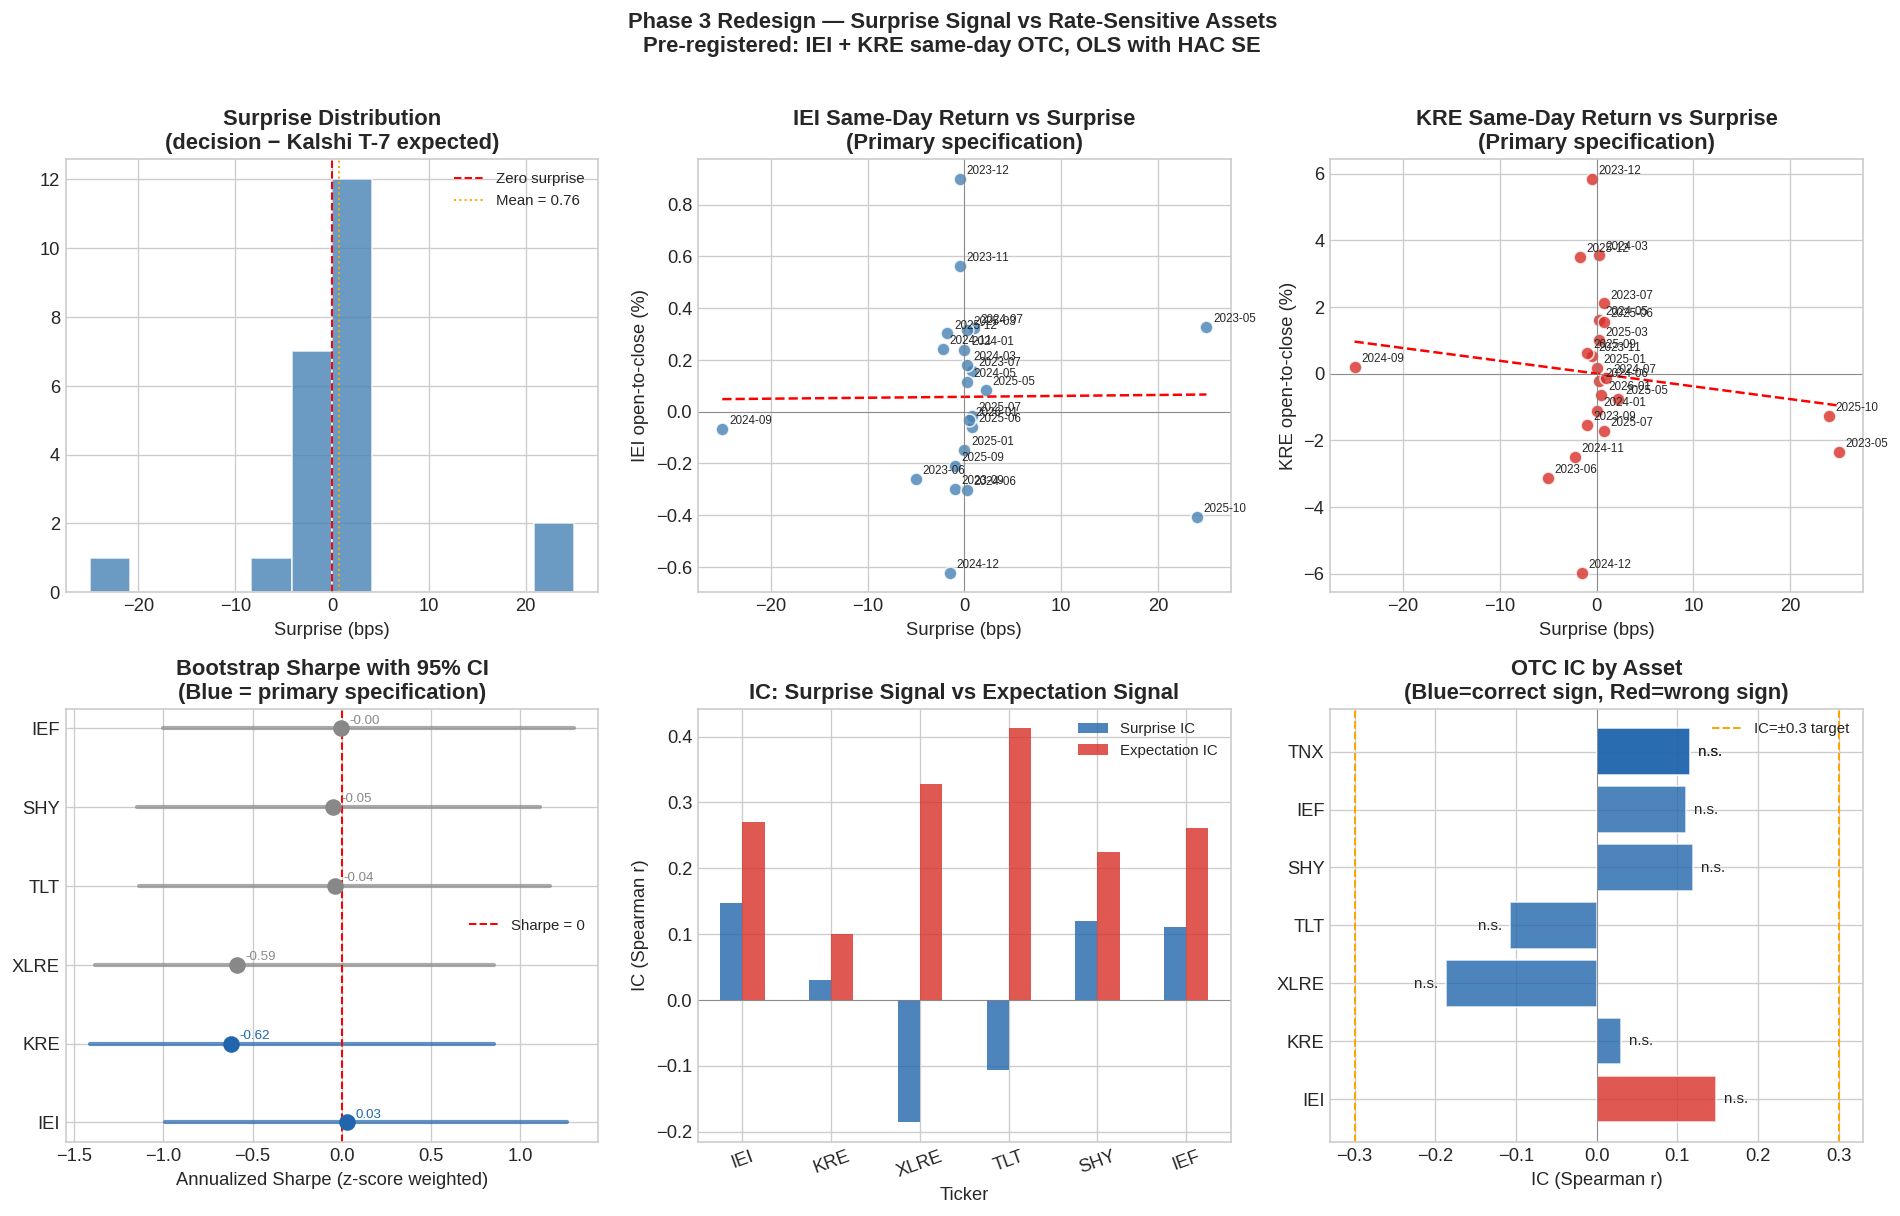

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# G: Visualizations
# ═══════════════════════════════════════════════════════════════════════════

# Add expectation column to port_df for IC comparison panel
port_df = port_df.merge(
    kalshi_signal_df[['fomc_date', SIGNAL_COL]],
    on='fomc_date', how='left'
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Panel 1: Surprise distribution
ax = axes[0, 0]
ax.hist(port_df['surprise_bps'].dropna(), bins=12, color='steelblue',
        alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero surprise')
ax.axvline(port_df['surprise_bps'].mean(), color='orange', linestyle=':',
           linewidth=1.2, label=f"Mean = {port_df['surprise_bps'].mean():.2f}")
ax.set_title('Surprise Distribution\n(decision − Kalshi T-7 expected)', fontweight='bold')
ax.set_xlabel('Surprise (bps)')
ax.legend(fontsize=9)

# Panel 2: IEI OTC vs surprise scatter
ax = axes[0, 1]
if 'IEI_otc' in port_df.columns:
    valid = port_df[['surprise_bps', 'IEI_otc', 'fomc_date']].dropna()
    ax.scatter(valid['surprise_bps'], valid['IEI_otc'] * 100,
               color='steelblue', s=60, alpha=0.8, edgecolors='white')
    if len(valid) >= 3:
        z  = np.polyfit(valid['surprise_bps'], valid['IEI_otc'] * 100, 1)
        px = np.linspace(valid['surprise_bps'].min(), valid['surprise_bps'].max(), 100)
        ax.plot(px, np.poly1d(z)(px), 'red', linestyle='--', linewidth=1.5)
    for _, row in valid.iterrows():
        ax.annotate(str(row['fomc_date'])[:7], (row['surprise_bps'], row['IEI_otc']*100),
                    textcoords='offset points', xytext=(4, 3), fontsize=7)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Surprise (bps)')
    ax.set_ylabel('IEI open-to-close (%)')
    ax.set_title('IEI Same-Day Return vs Surprise\n(Primary specification)', fontweight='bold')
else:
    axes[0, 1].text(0.5, 0.5, 'IEI_otc not available', ha='center', va='center',
                    transform=axes[0, 1].transAxes, fontsize=12, color='gray')

# Panel 3: KRE OTC vs surprise scatter
ax = axes[0, 2]
if 'KRE_otc' in port_df.columns:
    valid = port_df[['surprise_bps', 'KRE_otc', 'fomc_date']].dropna()
    ax.scatter(valid['surprise_bps'], valid['KRE_otc'] * 100,
               color='#d73027', s=60, alpha=0.8, edgecolors='white')
    if len(valid) >= 3:
        z  = np.polyfit(valid['surprise_bps'], valid['KRE_otc'] * 100, 1)
        px = np.linspace(valid['surprise_bps'].min(), valid['surprise_bps'].max(), 100)
        ax.plot(px, np.poly1d(z)(px), 'red', linestyle='--', linewidth=1.5)
    for _, row in valid.iterrows():
        ax.annotate(str(row['fomc_date'])[:7], (row['surprise_bps'], row['KRE_otc']*100),
                    textcoords='offset points', xytext=(4, 3), fontsize=7)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Surprise (bps)')
    ax.set_ylabel('KRE open-to-close (%)')
    ax.set_title('KRE Same-Day Return vs Surprise\n(Primary specification)', fontweight='bold')
else:
    axes[0, 2].text(0.5, 0.5, 'KRE_otc not available', ha='center', va='center',
                    transform=axes[0, 2].transAxes, fontsize=12, color='gray')

# Panel 4: Bootstrap Sharpe CI
ax = axes[1, 0]
tickers_boot = [t for t, v in portfolio_results.items()
                if not np.isnan(v['sharpe'])][:6]
if tickers_boot:
    sharpes = [portfolio_results[t]['sharpe'] for t in tickers_boot]
    ci_los  = [portfolio_results[t]['ci_lo']  for t in tickers_boot]
    ci_his  = [portfolio_results[t]['ci_hi']  for t in tickers_boot]
    colors_b = ['#2166ac' if portfolio_results[t]['is_primary'] else '#888888'
                for t in tickers_boot]
    for i, (t, s, lo, hi, col) in enumerate(
            zip(tickers_boot, sharpes, ci_los, ci_his, colors_b)):
        ax.plot([lo, hi], [i, i], color=col, linewidth=2.5, alpha=0.7)
        ax.scatter(s, i, color=col, s=80, zorder=5)
        ax.annotate(f'{s:.2f}', (s, i), textcoords='offset points',
                    xytext=(5, 3), fontsize=8, color=col)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Sharpe = 0')
    ax.set_yticks(list(range(len(tickers_boot))))
    ax.set_yticklabels(tickers_boot)
    ax.set_xlabel('Annualized Sharpe (z-score weighted)')
    ax.set_title('Bootstrap Sharpe with 95% CI\n(Blue = primary specification)',
                 fontweight='bold')
    ax.legend(fontsize=9)

# Panel 5: IC comparison — surprise vs expectation
ax = axes[1, 1]
ic_compare_data = []
for ret_col in [c for c in port_df.columns if '_otc' in c]:
    ticker = ret_col.replace('_otc', '')
    valid = port_df[['surprise_bps', SIGNAL_COL, ret_col]].dropna()
    if len(valid) < 5:
        continue
    ic_surp, _ = stats.spearmanr(valid['surprise_bps'], valid[ret_col])
    ic_exp,  _ = stats.spearmanr(valid[SIGNAL_COL],    valid[ret_col])
    ic_compare_data.append({'Ticker': ticker,
                             'Surprise IC': ic_surp, 'Expectation IC': ic_exp})

if ic_compare_data:
    ic_comp_df = pd.DataFrame(ic_compare_data).set_index('Ticker')
    ic_comp_df.plot(kind='bar', ax=ax, color=['#2166ac', '#d73027'], alpha=0.8)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title('IC: Surprise Signal vs Expectation Signal', fontweight='bold')
    ax.set_ylabel('IC (Spearman r)')
    ax.tick_params(axis='x', labelrotation=20)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'Insufficient data for IC comparison',
            ha='center', va='center', transform=ax.transAxes, fontsize=11, color='gray')

# Panel 6: Regression IC summary (OTC only)
ax = axes[1, 2]
otc_regs = reg_df[reg_df['horizon'] == 'OTC'].copy()
if len(otc_regs) > 0:
    colors_reg = ['#2166ac' if r['sign_correct'] else '#d73027'
                  for _, r in otc_regs.iterrows()]
    bars = ax.barh(otc_regs['ticker'].tolist(), otc_regs['IC'].tolist(),
                   color=colors_reg, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.axvline( 0.3, color='orange', linestyle='--', linewidth=1.2, label='IC=±0.3 target')
    ax.axvline(-0.3, color='orange', linestyle='--', linewidth=1.2)
    for bar, (_, row) in zip(bars, otc_regs.iterrows()):
        label = row['sig'] if row['sig'] else 'n.s.'
        ax.text(bar.get_width() + 0.01 if bar.get_width() >= 0 else bar.get_width() - 0.01,
                bar.get_y() + bar.get_height() / 2,
                label, va='center', ha='left' if bar.get_width() >= 0 else 'right', fontsize=9)
    ax.set_xlabel('IC (Spearman r)')
    ax.set_title('OTC IC by Asset\n(Blue=correct sign, Red=wrong sign)', fontweight='bold')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'No OTC regression results', ha='center', va='center',
            transform=ax.transAxes, fontsize=11, color='gray')

plt.suptitle('Phase 3 Redesign — Surprise Signal vs Rate-Sensitive Assets\n'
             'Pre-registered: IEI + KRE same-day OTC, OLS with HAC SE',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig13_phase3_redesign.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# H: Save all results for Phase 4 report
# ═══════════════════════════════════════════════════════════════════════════

# Save regression results
reg_df.to_csv(RESULTS_PATH + 'regression_results.csv', index=False)

# Save portfolio results
port_summary = pd.DataFrame([
    {'ticker': t, **v} for t, v in portfolio_results.items()
])
port_summary.to_csv(RESULTS_PATH + 'portfolio_results.csv', index=False)

# Save full meeting-level data
port_df.to_csv(RESULTS_PATH + 'meeting_data.csv', index=False)

# Save JSON summary for report auto-fill
summary_dict = {
    'n_meetings': len(port_df),
    'signal_col': SIGNAL_COL,
    'demeaned': DEMEAN_SURPRISE,
    'corr_t7_t1': float(r_tt) if not np.isnan(r_tt) else None,
    'surprise_mean': float(port_df['surprise_bps'].mean()),
    'surprise_std':  float(port_df['surprise_bps'].std()),
    'primary_assets': ['IEI', 'KRE'],
    'regression': {
        r['ticker'] + '_' + r['horizon']: {
            'beta_pct_per_bp': round(r['beta_pct_per_bp'], 5),
            't_hac': round(r['t_hac'], 3),
            'p_hac': round(r['p_hac'], 4),
            'R2': round(r['R2'], 4),
            'IC': round(r['IC'], 4),
            'sig': r['sig'],
        } for _, r in reg_df.iterrows()
    },
    'portfolio': {
        t: {'sharpe': round(v['sharpe'], 3),
            'ci_lo': round(v['ci_lo'], 3),
            'ci_hi': round(v['ci_hi'], 3),
            'ci_excludes_zero': bool(v['ci_lo'] > 0 or v['ci_hi'] < 0)}
        for t, v in portfolio_results.items()
    }
}

with open(RESULTS_PATH + 'summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=2)

print("=" * 60)
print("PHASE 3 REDESIGN — COMPLETE RESULTS SUMMARY")
print("=" * 60)
print(f"\nSignal: {SIGNAL_COL} (surprise = decision − expected)")
print(f"N meetings: {len(port_df)}")
print(f"Demeaned: {DEMEAN_SURPRISE}")
print(f"corr(T-7, T-1): {r_tt:.4f}" if not np.isnan(r_tt) else "corr(T-7, T-1): N/A")

print(f"\n--- Primary OTC Regressions (HAC SE) ---")
primary_otc = reg_df[reg_df['horizon'] == 'OTC']
print(primary_otc[['ticker','N','beta_pct_per_bp','t_hac','p_hac','R2','IC','sig']]
      .to_string(index=False))

print(f"\n--- Bootstrap Sharpe (z-score weighted) ---")
for t, v in portfolio_results.items():
    if v['is_primary']:
        print(f"  {t}: Sharpe={v['sharpe']:.3f}  CI=[{v['ci_lo']:.3f}, {v['ci_hi']:.3f}]  "
              f"{'CI excludes zero ✓' if v['ci_lo']>0 or v['ci_hi']<0 else 'CI includes zero'}")

print(f"\nAll results saved to: {RESULTS_PATH}")
print("Figure saved: fig13_phase3_redesign.png")

PHASE 3 REDESIGN — COMPLETE RESULTS SUMMARY

Signal: kalshi_expected_t7 (surprise = decision − expected)
N meetings: 23
Demeaned: False
corr(T-7, T-1): 0.9993

--- Primary OTC Regressions (HAC SE) ---
ticker  N  beta_pct_per_bp     t_hac    p_hac       R2        IC sig
   IEI 23         0.000358  0.046878 0.962610 0.000094  0.147855    
   KRE 23        -0.038326 -1.569818 0.116458 0.019981  0.030762    
  XLRE 23        -0.024306 -1.485043 0.137533 0.028900 -0.186060    
   TLT 23        -0.000941 -0.062394 0.950249 0.000178 -0.107170    
   SHY 23        -0.000288 -0.074708 0.940447 0.000274  0.119078    
   IEF 23        -0.000066 -0.006259 0.995006 0.000002  0.111140    
   TNX 23         0.080774  0.803598 0.421629 0.017097  0.115137    
   TNX 23         0.080774  0.803598 0.421629 0.017097  0.115137    

--- Bootstrap Sharpe (z-score weighted) ---
  IEI: Sharpe=0.031  CI=[-0.993, 1.262]  CI includes zero
  KRE: Sharpe=-0.618  CI=[-1.411, 0.851]  CI includes zero

All results sav

In [15]:
# Check which weekday fomc_dates fall on
port_df['fomc_weekday'] = pd.to_datetime(port_df['fomc_date']).dt.day_name()
print(port_df[['fomc_date', 'fomc_weekday', 'surprise_bps', 'IEI_otc']].to_string())

    fomc_date fomc_weekday  surprise_bps   IEI_otc
0  2023-05-03    Wednesday         25.00  0.003292
1  2023-06-14    Wednesday         -5.00 -0.002590
2  2023-07-26    Wednesday          0.75  0.001563
3  2023-09-20    Wednesday         -1.00 -0.002991
4  2023-11-01    Wednesday         -0.50  0.005618
5  2023-12-13    Wednesday         -0.50  0.009009
6  2024-01-31    Wednesday          0.00  0.002389
7  2024-03-20    Wednesday          0.25  0.001822
8  2024-05-01    Wednesday          0.25  0.001147
9  2024-06-12    Wednesday          0.25 -0.003026
10 2024-07-31    Wednesday          1.00  0.003240
11 2024-09-18    Wednesday        -25.00 -0.000667
12 2024-11-07     Thursday         -2.25  0.002411
13 2024-12-18    Wednesday         -1.50 -0.006211
14 2025-01-29    Wednesday          0.00 -0.001463
15 2025-03-19    Wednesday          0.25  0.003156
16 2025-05-07    Wednesday          2.25  0.000846
17 2025-06-18    Wednesday          0.75 -0.000593
18 2025-07-30    Wednesday     